In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")



In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

fake["label"] = "Fake"
real["label"] = "Real"

df = pd.concat([fake, real])

df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Fake


In [ ]:
df.shape

(44898, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 2.1+ MB


In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
df["label"].value_counts()

,count
label,
Fake,23481
Real,21417


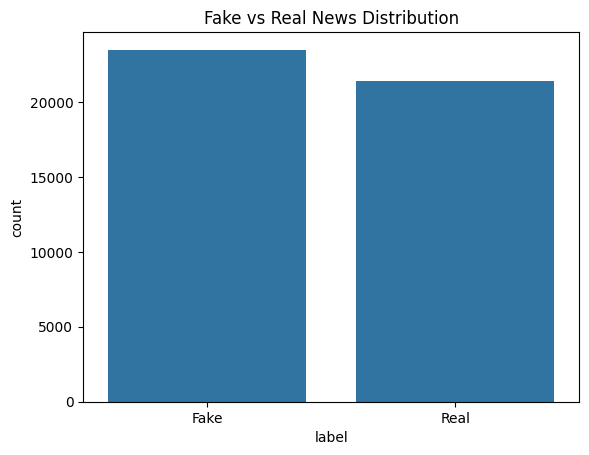

In [ ]:
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News Distribution")
plt.show()

In [ ]:
df["text_length"] = df["text"].apply(len)

In [ ]:
df["text_length"] = df["text"].apply(len)

**Insight**:

Some news articles are very long

Some are short

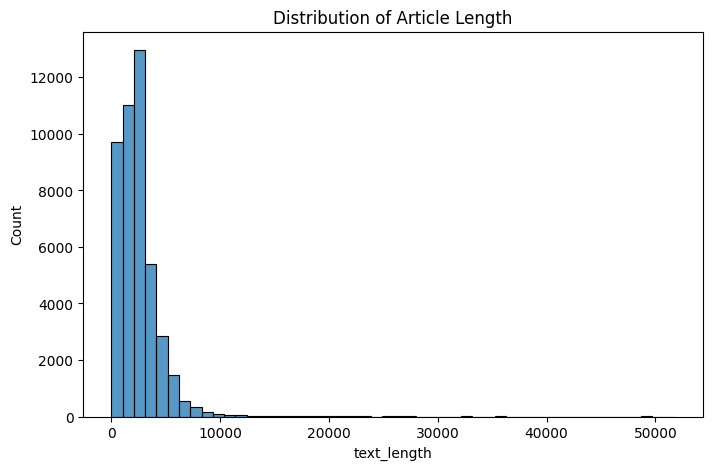

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["text_length"], bins=50)

plt.title("Distribution of Article Length")
plt.show()

**Fake vs Real Article Length**

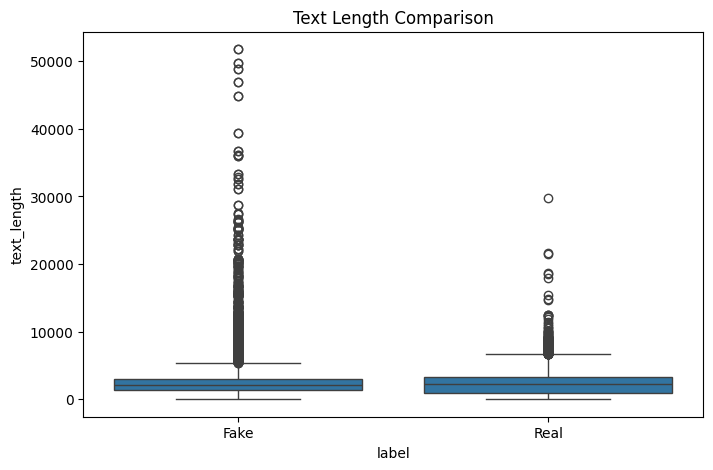

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="label", y="text_length", data=df)

plt.title("Text Length Comparison")
plt.show()

In [ ]:
from collections import Counter

all_words = " ".join(df["text"]).split()

Counter(all_words).most_common(20)

[('the', 905825),
 ('to', 529815),
 ('of', 437532),
 ('and', 392470),
 ('a', 390084),
 ('in', 322378),
 ('that', 220928),
 ('on', 181758),
 ('s', 172259),
 ('for', 166256),
 ('is', 160009),
 ('was', 114171),
 ('with', 113690),
 ('he', 105668),
 ('Trump', 101305),
 ('as', 96723),
 ('The', 95236),
 ('said', 93137),
 ('by', 92699),
 ('his', 92058)]

In [ ]:
!!pip install wordcloud

['Requirement already satisfied: wordcloud in /usr/local/lib/python3.12/dist-packages (1.9.6)',
 'Requirement already satisfied: numpy>=1.19.3 in /usr/local/lib/python3.12/dist-packages (from wordcloud) (2.0.2)',
 'Requirement already satisfied: pillow in /usr/local/lib/python3.12/dist-packages (from wordcloud) (11.3.0)',
 'Requirement already satisfied: matplotlib in /usr/local/lib/python3.12/dist-packages (from wordcloud) (3.10.0)',
 'Requirement already satisfied: contourpy>=1.0.1 in /usr/local/lib/python3.12/dist-packages (from matplotlib->wordcloud) (1.3.3)',
 'Requirement already satisfied: cycler>=0.10 in /usr/local/lib/python3.12/dist-packages (from matplotlib->wordcloud) (0.12.1)',
 'Requirement already satisfied: fonttools>=4.22.0 in /usr/local/lib/python3.12/dist-packages (from matplotlib->wordcloud) (4.62.0)',
 'Requirement already satisfied: kiwisolver>=1.3.1 in /usr/local/lib/python3.12/dist-packages (from matplotlib->wordcloud) (1.5.0)',
 'Requirement already satisfied: 

**Word Cloud Visualization**

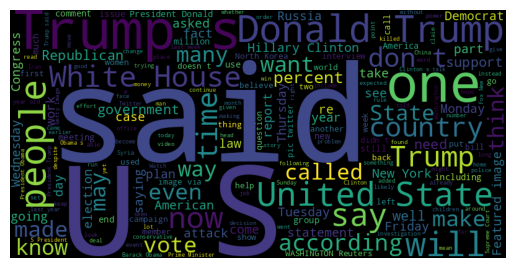

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["text"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

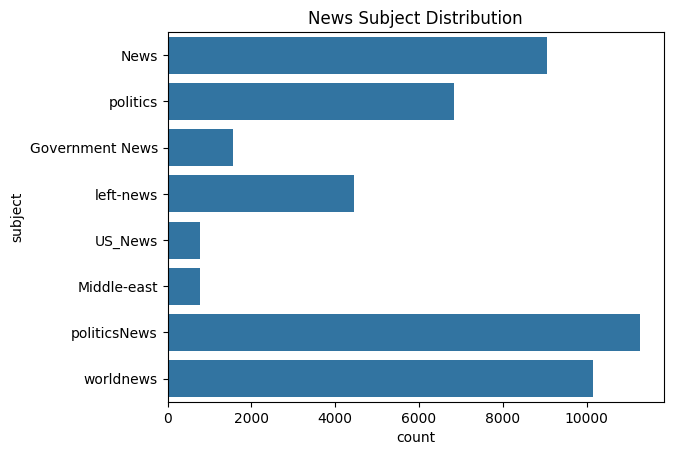

In [ ]:
sns.countplot(y="subject", data=df)
plt.title("News Subject Distribution")
plt.show()

In [ ]:
df["content"] = df["title"] + " " + df["text"]

In [ ]:
X = df["content"]
y = df["label"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)   # Fake=0, Real=1

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

 **TF-IDF Vectorizer.**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

**Train ML Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_vec, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_vec)

In [ ]:
y_pred

array([0, 1, 1, ..., 0, 0, 0])

**Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.987305122494432
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4733
           1       0.98      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



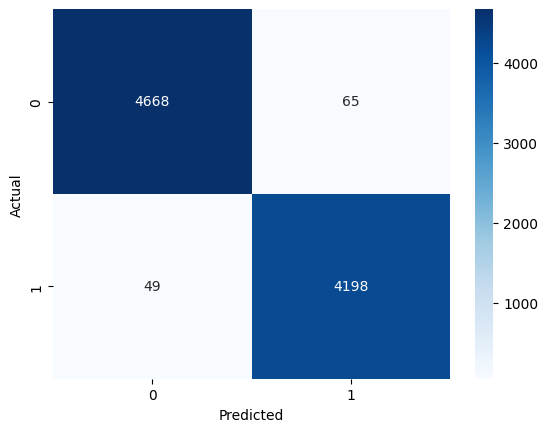

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_vec, y_train)

pred_nb = nb.predict(X_test_vec)

print("NB Accuracy:", accuracy_score(y_test, pred_nb))

NB Accuracy: 0.9296213808463252


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train_vec, y_train)

pred_rf = rf.predict(X_test_vec)

print("RF Accuracy:", accuracy_score(y_test, pred_rf))

RF Accuracy: 0.9974387527839643


In [ ]:
import pickle

pickle.dump(model, open("fake_news_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [ ]:
def predict_news(news):

    vect = vectorizer.transform([news])

    prediction = model.predict(vect)

    if prediction[0] == 0:
        return "Fake News"
    else:
        return "Real News"

In [ ]:
predict_news("Breaking news government announces new policy")

'Fake News'